# 03. Statistical analysis

**Owner:** Anibal  \
**Inputs:** see `config/paths.yml`  \
**Outputs:** figures to `reports/figures/`, data to `data/processed/`

## Purpose

Question A: Are demographic ageing and rural depopulation associated  with wildfire incidence and with burned-area impact at the municipality level?


## Setup

In [1]:
import sys
import warnings
from pathlib import Path

# Make the src-layout package importable when the notebook kernel is not installed with -e .
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from wildfires.config import STUDY_YEARS
from wildfires.io import load_icnf, load_panel
from wildfires.viz import apply_theme

apply_theme()
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

## Load panel

### INE (population dataset)

In [2]:
panel = load_panel()
panel = panel.loc[
    panel["year"].between(STUDY_YEARS[0], STUDY_YEARS[1])
].copy()
panel["share_over_65"] = panel["share_65_plus"] / 100
panel["share_over_75"] = panel["share_75_plus"] / 100
panel.head()

,dtcc,year,n_fires,n_fires_gt24h,burned_ha_total,burned_ha_forest,burned_ha_shrub,burned_ha_agric,burned_ha_total_ignited,burned_ha_forest_ignited,burned_ha_shrub_ignited,burned_ha_agric_ignited,n_fires_0_1ha,n_fires_1_10ha,n_fires_10_20ha,n_fires_20_50ha,n_fires_50_100ha,n_fires_100_500ha,n_fires_500_1000ha,n_fires_1000_plus_ha,cause_natural,cause_negligent,cause_intentional,cause_rekindle,cause_unknown,cause_uninvestigated,effis_n_fires,effis_burnt_ha_total,effis_burnt_ha_median,effis_burnt_ha_max,...,percna2k_mean,municipality_area_km2,burn_rate,burn_rate_ignited,territory,pop_total,pop_0_14,pop_15_24,pop_25_64,pop_65_plus,pop_75_plus,share_0_14,share_15_24,share_25_64,share_65_plus,share_75_plus,aging_index,old_age_dependency,pop_density,growth_effective,growth_natural,growth_migratory,birth_rate,death_rate,aging_index_ine,renewal_index,old_age_dependency_ine,longevity_index,share_over_65,share_over_75
0,0101,2019,50,1,516.513221,502.578221,6.632000,7.303000,NaN,NaN,NaN,NaN,41,4,0,1,2,1,0,1,0,15,15,3,17,0,4.0,365.0,52.5,211.0,...,19.888143,335.489179,0.015396,NaN,Águeda,46075.0,5494.0,4628.0,24782.0,11171.0,5221.0,11.924037,10.044493,53.786218,24.245252,11.331525,203.330906,37.983679,137.4,0.18,-0.18,0.36,7.8,9.6,203.3,69.2,38.0,46.7,0.242453,0.113315
1,0101,2020,30,0,324.955500,318.683000,5.363000,0.909500,NaN,NaN,NaN,NaN,30,0,0,0,0,0,0,0,0,4,16,0,10,0,NaN,NaN,NaN,NaN,...,NaN,335.489179,0.009686,NaN,Águeda,46349.0,5448.0,4716.0,24760.0,11425.0,5391.0,11.754299,10.174977,53.420786,24.649939,11.631319,209.709985,38.760347,138.2,0.59,-0.35,0.94,7.5,11.0,209.7,70.9,38.8,47.2,0.246499,0.116313
2,0101,2021,28,0,1.876500,0.971500,0.325000,0.580000,NaN,NaN,NaN,NaN,28,0,0,0,0,0,0,0,0,8,17,1,2,0,NaN,NaN,NaN,NaN,...,NaN,335.489179,0.000056,NaN,Águeda,46247.0,5535.0,4512.0,24231.0,11969.0,5741.0,11.968344,9.756309,52.394750,25.880598,12.413778,216.242096,41.641443,137.9,0.02,-0.51,0.54,6.6,11.8,216.2,68.3,41.6,48.0,0.258806,0.124138
3,0101,2022,25,0,112.222007,103.785939,2.726578,5.709491,NaN,NaN,NaN,NaN,24,1,0,0,0,0,0,0,1,7,10,2,5,0,2.0,212.0,106.0,211.0,...,0.000000,335.489179,0.003345,NaN,Águeda,46495.0,5626.0,4446.0,24154.0,12269.0,5850.0,12.100226,9.562319,51.949672,26.387784,12.581998,218.076786,42.898601,138.7,0.00,-0.42,0.42,7.5,11.7,218.1,67.0,42.9,47.7,0.263878,0.125820
4,0101,2023,32,0,27.548819,26.956370,0.416337,0.176112,NaN,NaN,NaN,NaN,29,2,1,0,0,0,0,0,0,16,11,3,2,0,4.0,14.0,2.5,8.0,...,46.980451,335.489179,0.000821,NaN,Águeda,47220.0,5611.0,4589.0,24500.0,12520.0,6085.0,11.882677,9.718340,51.884795,26.514189,12.886489,223.133131,43.040325,140.8,1.19,-0.49,1.67,6.6,11.5,223.1,68.3,43.0,48.6,0.265142,0.128865


In [3]:
panel

,dtcc,year,n_fires,n_fires_gt24h,burned_ha_total,burned_ha_forest,burned_ha_shrub,burned_ha_agric,burned_ha_total_ignited,burned_ha_forest_ignited,burned_ha_shrub_ignited,burned_ha_agric_ignited,n_fires_0_1ha,n_fires_1_10ha,n_fires_10_20ha,n_fires_20_50ha,n_fires_50_100ha,n_fires_100_500ha,n_fires_500_1000ha,n_fires_1000_plus_ha,cause_natural,cause_negligent,cause_intentional,cause_rekindle,cause_unknown,cause_uninvestigated,effis_n_fires,effis_burnt_ha_total,effis_burnt_ha_median,effis_burnt_ha_max,...,percna2k_mean,municipality_area_km2,burn_rate,burn_rate_ignited,territory,pop_total,pop_0_14,pop_15_24,pop_25_64,pop_65_plus,pop_75_plus,share_0_14,share_15_24,share_25_64,share_65_plus,share_75_plus,aging_index,old_age_dependency,pop_density,growth_effective,growth_natural,growth_migratory,birth_rate,death_rate,aging_index_ine,renewal_index,old_age_dependency_ine,longevity_index,share_over_65,share_over_75
0,0101,2019,50,1,516.513221,502.578221,6.632000,7.303000,NaN,NaN,NaN,NaN,41,4,0,1,2,1,0,1,0,15,15,3,17,0,4.0,365.0,52.5,211.0,...,19.888143,335.489179,0.015396,NaN,Águeda,46075.0,5494.0,4628.0,24782.0,11171.0,5221.0,11.924037,10.044493,53.786218,24.245252,11.331525,203.330906,37.983679,137.4,0.18,-0.18,0.36,7.8,9.6,203.3,69.2,38.0,46.7,0.242453,0.113315
1,0101,2020,30,0,324.955500,318.683000,5.363000,0.909500,NaN,NaN,NaN,NaN,30,0,0,0,0,0,0,0,0,4,16,0,10,0,NaN,NaN,NaN,NaN,...,NaN,335.489179,0.009686,NaN,Águeda,46349.0,5448.0,4716.0,24760.0,11425.0,5391.0,11.754299,10.174977,53.420786,24.649939,11.631319,209.709985,38.760347,138.2,0.59,-0.35,0.94,7.5,11.0,209.7,70.9,38.8,47.2,0.246499,0.116313
2,0101,2021,28,0,1.876500,0.971500,0.325000,0.580000,NaN,NaN,NaN,NaN,28,0,0,0,0,0,0,0,0,8,17,1,2,0,NaN,NaN,NaN,NaN,...,NaN,335.489179,0.000056,NaN,Águeda,46247.0,5535.0,4512.0,24231.0,11969.0,5741.0,11.968344,9.756309,52.394750,25.880598,12.413778,216.242096,41.641443,137.9,0.02,-0.51,0.54,6.6,11.8,216.2,68.3,41.6,48.0,0.258806,0.124138
3,0101,2022,25,0,112.222007,103.785939,2.726578,5.709491,NaN,NaN,NaN,NaN,24,1,0,0,0,0,0,0,1,7,10,2,5,0,2.0,212.0,106.0,211.0,...,0.000000,335.489179,0.003345,NaN,Águeda,46495.0,5626.0,4446.0,24154.0,12269.0,5850.0,12.100226,9.562319,51.949672,26.387784,12.581998,218.076786,42.898601,138.7,0.00,-0.42,0.42,7.5,11.7,218.1,67.0,42.9,47.7,0.263878,0.125820
4,0101,2023,32,0,27.548819,26.956370,0.416337,0.176112,NaN,NaN,NaN,NaN,29,2,1,0,0,0,0,0,0,16,11,3,2,0,4.0,14.0,2.5,8.0,...,46.980451,335.489179,0.000821,NaN,Águeda,47220.0,5611.0,4589.0,24500.0,12520.0,6085.0,11.882677,9.718340,51.884795,26.514189,12.886489,223.133131,43.040325,140.8,1.19,-0.49,1.67,6.6,11.5,223.1,68.3,43.0,48.6,0.265142,0.128865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1663,1824,2020,12,0,0.803100,0.141000,0.460500,0.201600,NaN,NaN,NaN,NaN,12,0,0,0,0,0,0,0,0,4,6,0,2,0,NaN,NaN,NaN,NaN,...,NaN,193.650756,0.000041,NaN,Vouzela,9623.0,920.0,1004.0,4904.0,2795.0,1584.0,9.560428,10.433337,50.961239,29.044996,16.460563,303.804348,47.308734,49.7,0.04,-0.96,1.00,6.1,15.7,303.8,80.2,47.3,56.7,0.290450,0.164606
1664,1824,2021,8,0,14.628898,0.457618,14.166281,0.005000,NaN,NaN,NaN,NaN,6,2,0,0,0,0,0,0,0,6,1,0,1,0,1.0,10.0,10.0,10.0,...,0.000000,193.650756,0.000755,NaN,Vouzela,9593.0,952.0,924.0,4697.0,3020.0,1668.0,9.923903,9.632023,48.962785,31.481288,17.387679,317.226891,53.727095,49.5,-0.29,-0.86,0.57,6.5,15.1,317.2,67.7,53.7,55.2,0.314813,0.173877
1665,1824,2022,6,0,9.371000,4.860000,4.511000,0.000000,NaN,NaN,NaN,NaN,5,1,0,0,0,0,0,0,0,2,0,0,4,0,1.0,7.0,7.0,7.0,...,0.000000,193.650756,0.000484,NaN,Vouzela,9640.0,976.0,903.0,4724.0,3037.0,1654.0,10.124481,9.367220,49.004149,31.504149,17.157676,311.168033,53.971921,49.8,-0.71,-1.11,0.39,5.4,16.4,311.2,66.1,54.0,54.5,0.315041,0.171577
1666,1824,2023,7,0,2.577316,0.320000,2.207316,0.050000,NaN,NaN,NaN,N

### INCF (wildfire dataset)

In [4]:
wildfire_data = load_icnf(level="concelho")
wildfire_data.head()

,year,DTCC,Distrito,Concelho,Região NUTS III (2024),Num_IncendiosRurais,AreaArdPov_NoConcelho,AreaArdMato_NoConcelho,AreaArdAgric_NoConcelho,AreaArdTotal_NoConcelho,AreaArdPov_IncendioInicioConc,AreaArdMato_IncendioInicioConc,AreaArdAgric_IncendioInicioConc,AreaArdTotal_IncendioInicioConc,NIncRur_0_1ha,NIncRur_1_10ha,NIncRur_10_20ha,NIncRur_20_50ha,NIncRur_50_100ha,NIncRur_100_500ha,NIncRur_500_1000ha,NIncRur_1000_n_ha,NInc_Natural,NInc_Negligente,NInc_Intencionais,NInc_Reacendimentos,NInc_Desconhecida,NInc_NaoInvestigados,Ninc_Sup24h,dtcc
0,2001,101,Aveiro,Águeda,Região de Aveiro,84,NaN,NaN,NaN,NaN,7.8582,2.2464,0.000,10.1046,83,1,0,0,0,0,0,0,0,1,0,3,0,80,0,0101
1,2001,102,Aveiro,Albergaria-a-Velha,Região de Aveiro,87,NaN,NaN,NaN,NaN,55.8702,7.8302,0.000,63.7004,74,11,2,0,0,0,0,0,0,0,2,6,0,79,0,0102
2,2001,103,Aveiro,Anadia,Região de Aveiro,65,NaN,NaN,NaN,NaN,10.1313,1.9012,0.035,12.0675,62,3,0,0,0,0,0,0,0,1,5,2,0,57,0,0103
3,2001,104,Aveiro,Arouca,Área Metropolitana do Porto,253,NaN,NaN,NaN,NaN,564.0250,374.1800,0.220,938.4250,203,38,3,2,4,3,0,0,0,3,1,0,0,249,1,0104
4,2001,105,Aveiro,Aveiro,Região de Aveiro,39,NaN,NaN,NaN,NaN,0.0710,1.4612,0.570,2.1022,39,0,0,0,0,0,0,0,0,0,0,2,0,37,0,0105


### Municipality dimensions (data.gov)

In [5]:
municipality_dimensions = (
    panel[["dtcc", "territory", "municipality_area_km2"]]
    .drop_duplicates("dtcc")
    .rename(columns={"territory": "municipality", "municipality_area_km2": "area_km2"})
)
municipality_dimensions.head()

,dtcc,municipality,area_km2
0,0101,Águeda,335.489179
6,0102,Albergaria-a-Velha,157.669825
12,0103,Anadia,216.876662
18,0104,Arouca,329.013630
24,0105,Aveiro,178.632159


## Exploratory visualisations

### Fact checking the metrics - Study case: Penedono

In [6]:
pop_penedono = panel.loc[
    panel["territory"].eq("Penedono"),
    ["pop_0_14", "pop_15_24", "pop_25_64", "pop_65_plus", "pop_75_plus", "year"],
].sort_values("year")

In [7]:
pop_penedono

,pop_0_14,pop_15_24,pop_25_64,pop_65_plus,pop_75_plus,year
1590,243.0,281.0,1359.0,708.0,423.0,2019
1591,228.0,282.0,1355.0,707.0,403.0,2020
1592,223.0,273.0,1286.0,941.0,526.0,2021
1593,226.0,284.0,1319.0,957.0,533.0,2022
1594,223.0,275.0,1324.0,982.0,553.0,2023
1595,218.0,262.0,1332.0,996.0,553.0,2024


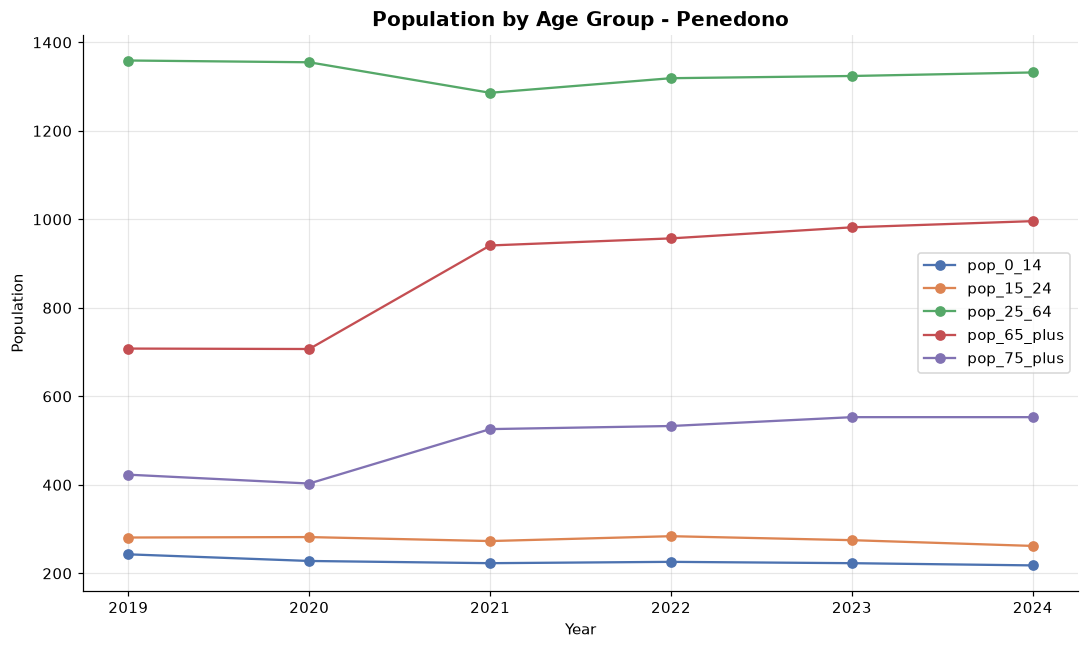

In [8]:

# Set year as index.
df = pop_penedono.set_index("year")

plt.figure(figsize=(10, 6))

population_cols = ["pop_0_14", "pop_15_24", "pop_25_64", "pop_65_plus", "pop_75_plus"]
for col in population_cols:
    plt.plot(df.index, df[col], marker="o", label=col)

plt.title("Population by Age Group - Penedono")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
wildfire_penedono = wildfire_data.loc[
    wildfire_data["year"].between(2001, 2025)
    & wildfire_data["Concelho"].eq("Penedono"),
    ["year", "Num_IncendiosRurais"],
].rename(columns={"Num_IncendiosRurais": "n_fires"})

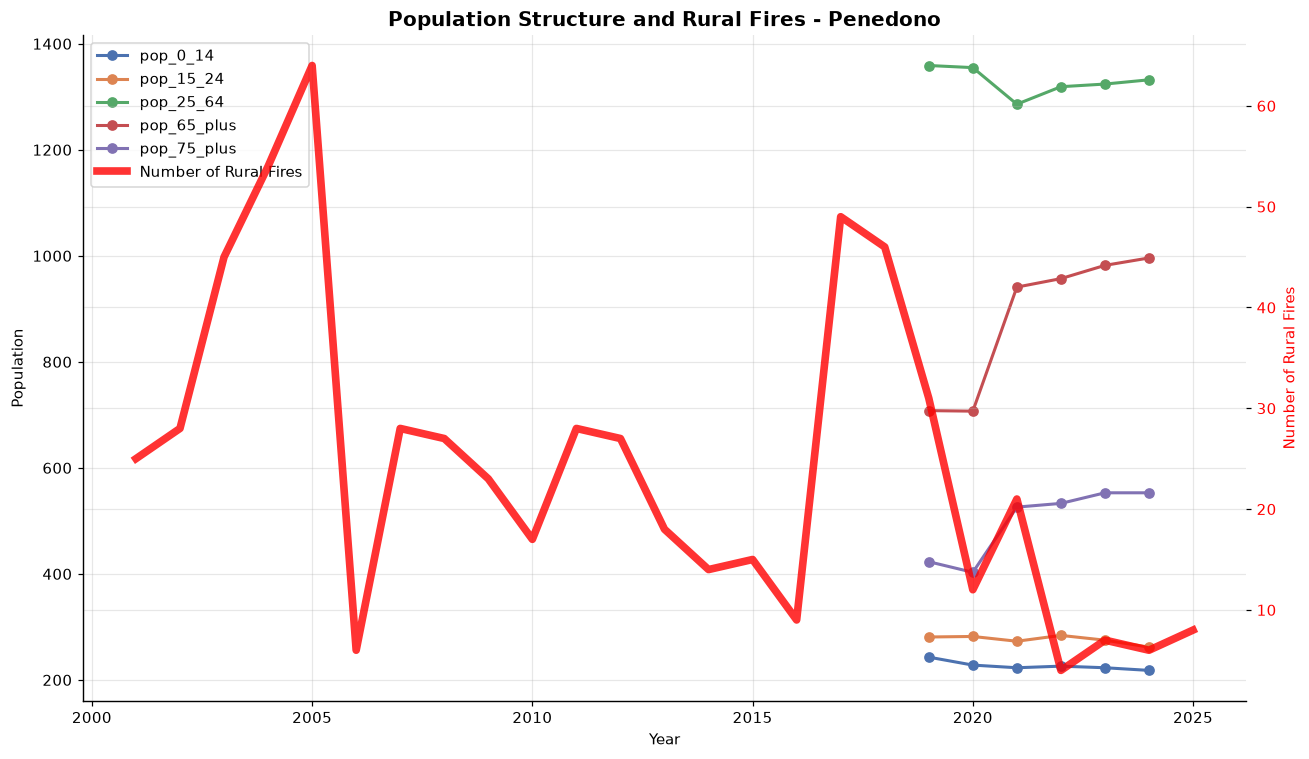

In [10]:
import matplotlib.pyplot as plt

pop_df = pop_penedono.set_index("year")
fire_df = wildfire_penedono.set_index("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

population_cols = ["pop_0_14", "pop_15_24", "pop_25_64", "pop_65_plus", "pop_75_plus"]
for col in population_cols:
    ax1.plot(pop_df.index, pop_df[col], marker="o", linewidth=2, label=col)

ax1.set_xlabel("Year")
ax1.set_ylabel("Population")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    fire_df.index,
    fire_df["n_fires"],
    color="red",
    linewidth=5,
    alpha=0.8,
    label="Number of Rural Fires",
)
ax2.set_ylabel("Number of Rural Fires", color="red")
ax2.tick_params(axis="y", labelcolor="red")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Population Structure and Rural Fires - Penedono")
plt.tight_layout()
plt.show()

**Conclusion:** Data shows a specific spike in 2021 both in ageing of the population and number of rural fires which may indicate the a link between the two variables or simply chance. However the number of fires was low in 2025, while in reality, the municipality of Penedono was devastated in 2025. Therefore, we conclude that the number of fires may not represent a good metric to represent the damage. Let's investigate other metrics.

### Burned area ratio - Penedono

In this chapter, we investigate the burned area ratio as a severity measure. This metric has been used in scientific research related to socio-economic impact [@chas_amil2022], which is seems adequate to our research question.

In [11]:
# Build one municipality-year dataset for burned-area ratio and population ageing.
fire_area = wildfire_data[
    ["dtcc", "year", "AreaArdTotal_IncendioInicioConc", "AreaArdTotal_NoConcelho"]
].copy()

fire_area["burned_area_ha"] = pd.to_numeric(
    fire_area["AreaArdTotal_IncendioInicioConc"], errors="coerce"
).fillna(pd.to_numeric(fire_area["AreaArdTotal_NoConcelho"], errors="coerce"))
fire_area = (
    fire_area.groupby(["dtcc", "year"], as_index=False, dropna=False)["burned_area_ha"]
    .sum(min_count=1)
)

municipality_area = municipality_dimensions.copy()
municipality_area["municipality_area_ha"] = municipality_area["area_km2"] * 100

older_population = panel[
    ["dtcc", "year", "pop_65_plus", "pop_75_plus"]
].rename(
    columns={
        "pop_65_plus": "population_over_65",
        "pop_75_plus": "population_over_75",
    }
)

burned_area_ratio = (
    fire_area
    .merge(municipality_area, on="dtcc", how="left", validate="many_to_one")
    .merge(older_population, on=["dtcc", "year"], how="left", validate="one_to_one")
)
burned_area_ratio["burned_area_ratio"] = (
    burned_area_ratio["burned_area_ha"] / burned_area_ratio["municipality_area_ha"]
)
burned_area_ratio["burned_area_ratio_pct"] = burned_area_ratio["burned_area_ratio"] * 100

burned_area_ratio = burned_area_ratio[
    [
        "dtcc", "municipality", "year", "burned_area_ha", "area_km2",
        "municipality_area_ha", "burned_area_ratio", "burned_area_ratio_pct",
        "population_over_65", "population_over_75",
    ]
].sort_values(["municipality", "year"]).reset_index(drop=True)

burned_area_ratio

,dtcc,municipality,year,burned_area_ha,area_km2,municipality_area_ha,burned_area_ratio,burned_area_ratio_pct,population_over_65,population_over_75
0,1401,Abrantes,2001,225.144000,715.181057,71518.105750,0.003148,0.314807,NaN,NaN
1,1401,Abrantes,2002,105.748100,715.181057,71518.105750,0.001479,0.147862,NaN,NaN
2,1401,Abrantes,2003,16062.955000,715.181057,71518.105750,0.224600,22.459984,NaN,NaN
3,1401,Abrantes,2004,1158.198100,715.181057,71518.105750,0.016194,1.619447,NaN,NaN
4,1401,Abrantes,2005,7645.993600,715.181057,71518.105750,0.106910,10.690990,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6916,1012,Óbidos,2021,7.372500,138.916965,13891.696517,0.000531,0.053071,3213.0,1519.0
6917,1012,Óbidos,2022,2.755000,138.916965,13891.696517,0.000198,0.019832,3375.0,1617.0
6918,1012,Óbidos,2023,65.990531,138.916965,13891.696517,0.004750,0.475036,3480.0,1667.0
6919,1012,Óbidos,2024,2.459019,138.916965,13891.696517,0.000177,0.017701,3558.0,1728.0


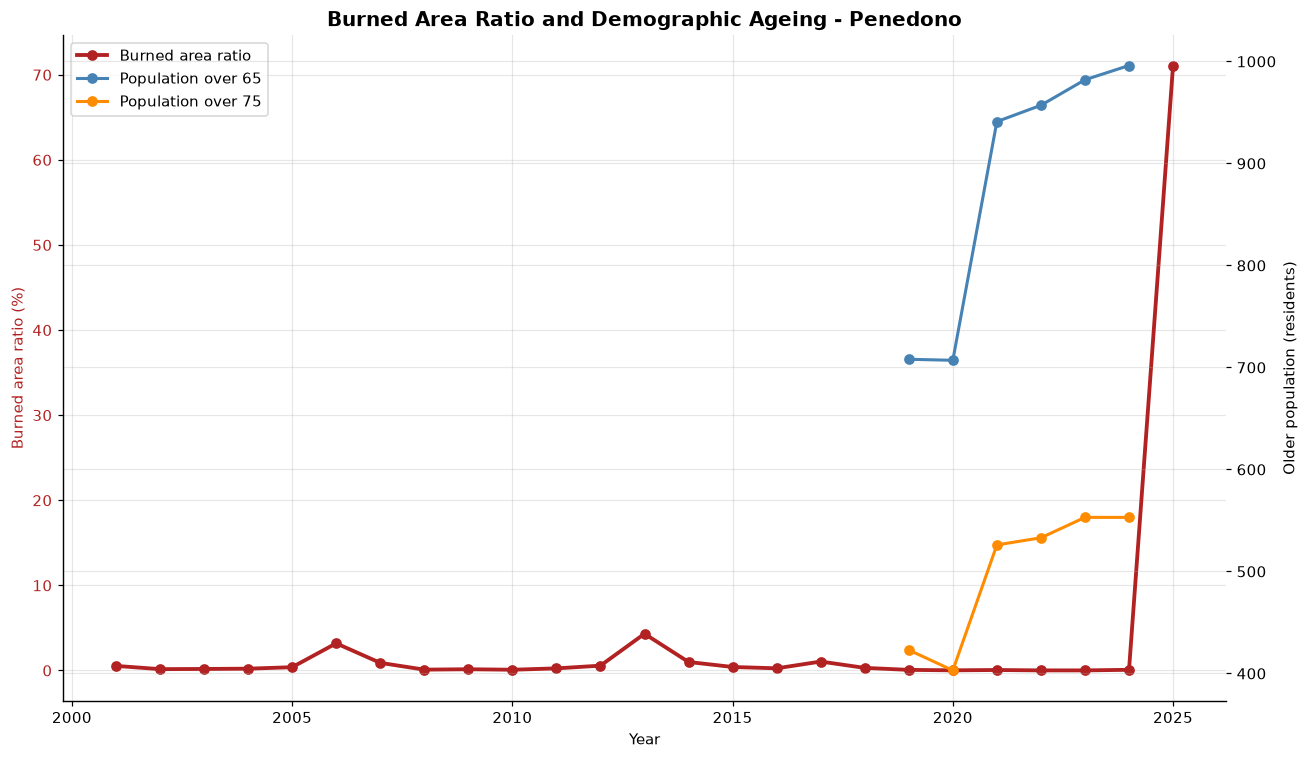

In [12]:
penedono_ratio = burned_area_ratio.loc[
    burned_area_ratio["municipality"].eq("Penedono"),
    ["year", "burned_area_ratio_pct", "population_over_65", "population_over_75"],
].sort_values("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    penedono_ratio["year"],
    penedono_ratio["burned_area_ratio_pct"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Burned area ratio",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Burned area ratio (%)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    penedono_ratio["year"],
    penedono_ratio["population_over_65"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Population over 65",
)
ax2.plot(
    penedono_ratio["year"],
    penedono_ratio["population_over_75"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Population over 75",
)
ax2.set_ylabel("Older population (residents)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Burned Area Ratio and Demographic Ageing - Penedono")
fig.tight_layout()
plt.show()

**Conclusion:** The percentage of burned area seems to represent a better metric for the damage caused by the fire (spike in 2025 correspond to the catastrophic fires over the last year). However, we cannot conclude if the demographic ageing after 2020 have contributed to these fires in 2025. Therefore, we should verify if there is a pattern over the country.

### Burned area ratio - Country level

In [13]:
# Build the country-level burned-area ratio and ageing dataset.
portugal_area = municipality_dimensions["area_km2"].sum()
portugal_area_ha = portugal_area * 100

country_burned_area = fire_area.groupby("year", as_index=False)["burned_area_ha"].sum(min_count=1)
country_burned_area["portugal_area_km2"] = portugal_area
country_burned_area["portugal_area_ha"] = portugal_area_ha
country_burned_area["burned_area_ratio"] = (
    country_burned_area["burned_area_ha"] / country_burned_area["portugal_area_ha"]
)
country_burned_area["burned_area_ratio_pct"] = country_burned_area["burned_area_ratio"] * 100

country_older_population = (
    panel.groupby("year", as_index=False)["pop_65_plus"]
    .sum(min_count=1)
    .rename(columns={"pop_65_plus": "population_over_65"})
)

portugal_burned_area_ratio = (
    country_burned_area
    .merge(country_older_population, on="year", how="left", validate="one_to_one")
    [[
        "year", "burned_area_ha", "portugal_area_km2", "portugal_area_ha",
        "burned_area_ratio", "burned_area_ratio_pct", "population_over_65",
    ]]
    .sort_values("year")
    .reset_index(drop=True)
)

portugal_burned_area_ratio

,year,burned_area_ha,portugal_area_km2,portugal_area_ha,burned_area_ratio,burned_area_ratio_pct,population_over_65
0,2001,117420.438657,88762.905044,8.876291e+06,0.013229,1.322855,NaN
1,2002,130849.078350,88762.905044,8.876291e+06,0.014741,1.474141,NaN
2,2003,471750.049431,88762.905044,8.876291e+06,0.053147,5.314721,NaN
3,2004,151369.876610,88762.905044,8.876291e+06,0.017053,1.705328,NaN
4,2005,346717.819232,88762.905044,8.876291e+06,0.039061,3.906112,NaN
5,2006,83705.863650,88762.905044,8.876291e+06,0.009430,0.943028,NaN
6,2007,36412.547360,88762.905044,8.876291e+06,0.004102,0.410223,NaN
7,2008,19897.219299,88762.905044,8.876291e+06,0.002242,0.224161,NaN
8,2009,92125.662431,88762.905044,8.876291e+06,0.010379,1.037885,NaN
9,2010,140953.185960,88762.905044,8.876291e+06,0.015880,1.587974,NaN


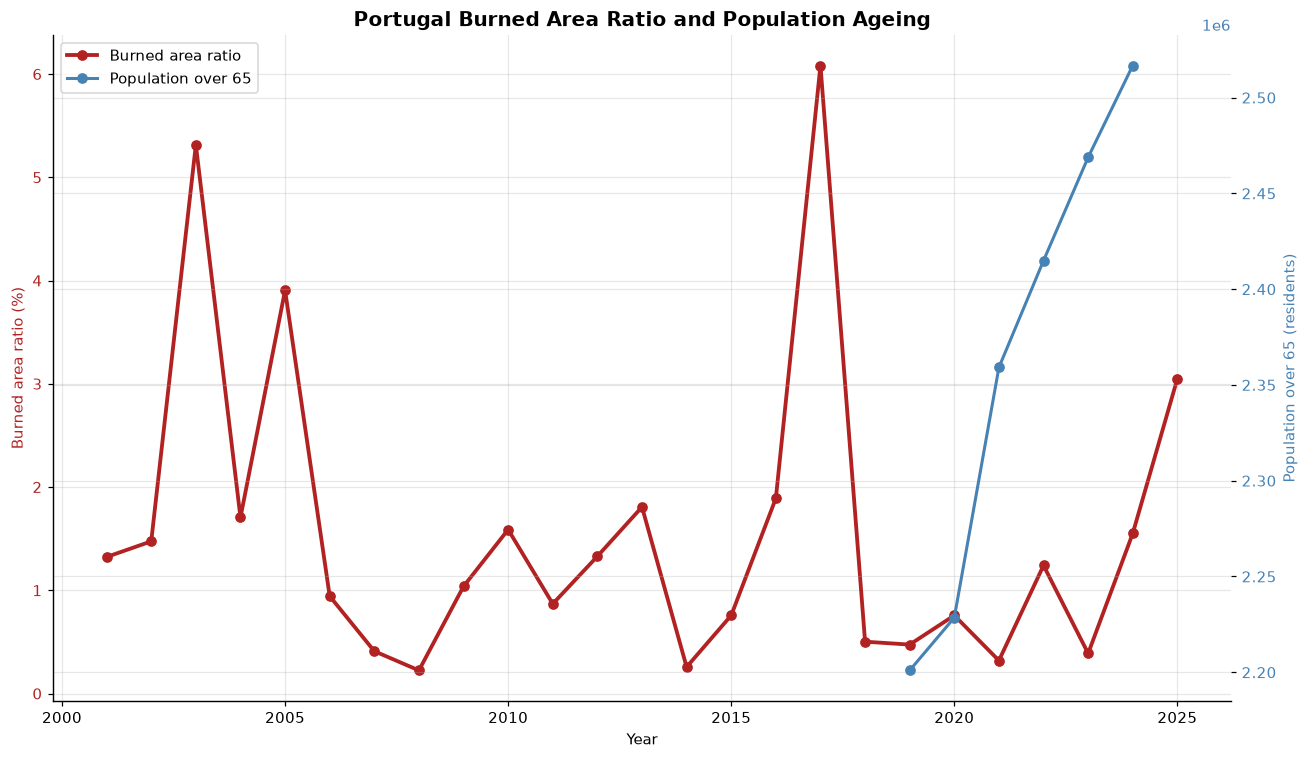

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    portugal_burned_area_ratio["year"],
    portugal_burned_area_ratio["burned_area_ratio_pct"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Burned area ratio",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Burned area ratio (%)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    portugal_burned_area_ratio["year"],
    portugal_burned_area_ratio["population_over_65"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Population over 65",
)
ax2.set_ylabel("Population over 65 (residents)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Portugal Burned Area Ratio and Population Ageing")
fig.tight_layout()
plt.show()

**Conclusion:** Over the country we can observe ciclic patterns of fire damage incidence. The population over 65 is drastically increasing in last years. However, we do not have data about population demographics before 2019, which makes it hard to draw conclusions about the relationship between the two variables. We therefore proceed with additional analysis.

## Analysis panel

Let's build an analysis panel by selecting fire related variables, agricultural burned area and aggregating to municipality and year.

In [15]:
# Panel: demographic ageing, rural depopulation, and agricultural fire outcomes.
analysis_panel = panel[
    [
        "dtcc", "year", "territory", "n_fires", "burned_ha_agric",
        "municipality_area_km2", "pop_total", "pop_65_plus", "pop_75_plus",
    ]
].copy()
analysis_panel = analysis_panel.rename(
    columns={
        "territory": "municipality",
        "n_fires": "rural_fire_count",
        "burned_ha_agric": "agricultural_burned_area_ha",
        "municipality_area_km2": "area_km2",
        "pop_total": "population_total",
        "pop_65_plus": "population_over_65",
        "pop_75_plus": "population_over_75",
    }
)
analysis_panel

,dtcc,year,municipality,rural_fire_count,agricultural_burned_area_ha,area_km2,population_total,population_over_65,population_over_75
0,0101,2019,Águeda,50,7.303000,335.489179,46075.0,11171.0,5221.0
1,0101,2020,Águeda,30,0.909500,335.489179,46349.0,11425.0,5391.0
2,0101,2021,Águeda,28,0.580000,335.489179,46247.0,11969.0,5741.0
3,0101,2022,Águeda,25,5.709491,335.489179,46495.0,12269.0,5850.0
4,0101,2023,Águeda,32,0.176112,335.489179,47220.0,12520.0,6085.0
...,...,...,...,...,...,...,...,...,...
1663,1824,2020,Vouzela,12,0.201600,193.650756,9623.0,2795.0,1584.0
1664,1824,2021,Vouzela,8,0.005000,193.650756,9593.0,3020.0,1668.0
1665,1824,2022,Vouzela,6,0.000000,193.650756,9640.0,3037.0,1654.0
1666,1824,2023,Vouzela,7,0.050000,193.650756,9765.0,3095.0,1691.0


Now we define population growth as a proxy to measure rural depopulation: Population growth = Population_t - Population_t-1 / Population_t-1

This allows to capture demographic change rather than population size.

In [16]:
analysis_panel["municipality_area_ha"] = analysis_panel["area_km2"] * 100
analysis_panel["agri_burned_ratio_pct"] = (
    analysis_panel["agricultural_burned_area_ha"]
    / analysis_panel["municipality_area_ha"]
    * 100
)
analysis_panel["share_over_65"] = (
    analysis_panel["population_over_65"] / analysis_panel["population_total"]
)
analysis_panel["share_over_75"] = (
    analysis_panel["population_over_75"] / analysis_panel["population_total"]
)
analysis_panel = analysis_panel.sort_values(["dtcc", "year"]).reset_index(drop=True)
analysis_panel["population_growth"] = analysis_panel.groupby("dtcc")[
    "population_total"
].pct_change()
analysis_panel["log_fire_count"] = np.log1p(
    analysis_panel["rural_fire_count"].clip(lower=0)
)

analysis_panel = analysis_panel.replace([np.inf, -np.inf], np.nan)
analysis_panel

,dtcc,year,municipality,rural_fire_count,agricultural_burned_area_ha,area_km2,population_total,population_over_65,population_over_75,municipality_area_ha,agri_burned_ratio_pct,share_over_65,share_over_75,population_growth,log_fire_count
0,0101,2019,Águeda,50,7.303000,335.489179,46075.0,11171.0,5221.0,33548.917888,0.021768,0.242453,0.113315,NaN,3.931826
1,0101,2020,Águeda,30,0.909500,335.489179,46349.0,11425.0,5391.0,33548.917888,0.002711,0.246499,0.116313,0.005947,3.433987
2,0101,2021,Águeda,28,0.580000,335.489179,46247.0,11969.0,5741.0,33548.917888,0.001729,0.258806,0.124138,-0.002201,3.367296
3,0101,2022,Águeda,25,5.709491,335.489179,46495.0,12269.0,5850.0,33548.917888,0.017018,0.263878,0.125820,0.005363,3.258097
4,0101,2023,Águeda,32,0.176112,335.489179,47220.0,12520.0,6085.0,33548.917888,0.000525,0.265142,0.128865,0.015593,3.496508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1663,1824,2020,Vouzela,12,0.201600,193.650756,9623.0,2795.0,1584.0,19365.075609,0.001041,0.290450,0.164606,0.000416,2.564949
1664,1824,2021,Vouzela,8,0.005000,193.650756,9593.0,3020.0,1668.0,19365.075609,0.000026,0.314813,0.173877,-0.003118,2.197225
1665,1824,2022,Vouzela,6,0.000000,193.650756,9640.0,3037.0,1654.0,19365.075609,0.000000,0.315041,0.171577,0.004899,1.945910
1666,1824,2023,Vouzela,7,0.050000,193.650756,9765.0,3095.0,1691.0,19365.075609,0.000258,0.316948,0.173169,0.012967,2.079442


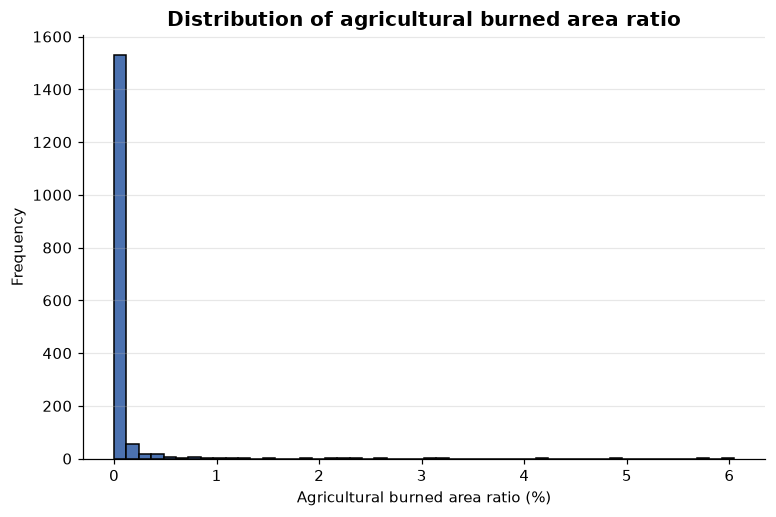

In [17]:
plt.figure(figsize=(8,5))
plt.hist(
    analysis_panel["agri_burned_ratio_pct"].dropna(),
    bins=50,
    edgecolor="black"
)
plt.xlabel("Agricultural burned area ratio (%)")
plt.ylabel("Frequency")
plt.title("Distribution of agricultural burned area ratio")
plt.show()

As expected, it is extremely skewed. We need to do log transformation before proceeding.

In [18]:
# use log1p because agricultural burned-area ratios are strongly right-skewed.
model_data = analysis_panel.copy()
model_data["log_agri_burned_ratio"] = np.log1p(
    model_data["agri_burned_ratio_pct"].clip(lower=0)
)

Now we can define municipality and year as fixed effects because of topography, climate, etc. Without these controls, differences between municipalities could bias the ageing coefficient.

In [19]:
def fit_fixed_effects(data, predictors, outcome="log_agri_burned_ratio"):
    required = ["dtcc", "year", outcome, *predictors]
    sample = data[required].dropna().copy()
    design = sample[predictors].copy()
    design = pd.concat(
        [
            design,
            pd.get_dummies(sample["dtcc"], prefix="municipality", drop_first=True, dtype=float),
            pd.get_dummies(sample["year"], prefix="year", drop_first=True, dtype=float),
        ],
        axis=1,
    )
    design = sm.add_constant(design.astype(float), has_constant="add")
    fit = sm.OLS(sample[outcome].astype(float), design).fit(
        cov_type="cluster",
        cov_kwds={"groups": sample["dtcc"]},
    )
    return fit, sample, design

ageing_model, ageing_sample, ageing_design = fit_fixed_effects(
    model_data,
    ["share_over_65"],
)
ageing_growth_model, ageing_growth_sample, ageing_growth_design = fit_fixed_effects(
    model_data,
    ["share_over_65", "population_growth"],
)

model_comparison = pd.DataFrame(
    {
        "model": ["Ageing + municipality/year effects", "Ageing + population growth + effects"],
        "observations": [len(ageing_sample), len(ageing_growth_sample)],
        "r_squared": [ageing_model.rsquared, ageing_growth_model.rsquared],
        "share_over_65_coef": [
            ageing_model.params["share_over_65"],
            ageing_growth_model.params["share_over_65"],
        ],
        "share_over_65_pvalue": [
            ageing_model.pvalues["share_over_65"],
            ageing_growth_model.pvalues["share_over_65"],
        ],
        "population_growth_coef": [
            np.nan,
            ageing_growth_model.params["population_growth"],
        ],
        "population_growth_pvalue": [
            np.nan,
            ageing_growth_model.pvalues["population_growth"],
        ],
    }
)
model_comparison

,model,observations,r_squared,share_over_65_coef,share_over_65_pvalue,population_growth_coef,population_growth_pvalue
0,Ageing + municipality/year effects,1666,0.204385,0.660899,0.041502,NaN,NaN
1,Ageing + population growth + effects,1388,0.230003,0.670382,0.080007,0.30292,0.066906


The coefficient on share_over_65 is 0.661 and statistically significant at the 5% level (p = 0.042). This means a municipality whose elderly increases from 20% to 21% is associated with roughly a 0.7% increase in agricultural burned-area intensity. However, adding population growth, the ageing coef remains positive but significance weakens. Adding population growth only increases r squared modestly (0.204 to 0.230).

**Conclusion:** Overall, the results provide limited evidence that demographic structure is associated with agricultural fire outcomes, although the magnitude and statistical significance of the effects are modest.

The demographic panel is limited to 2019-2024. Let's forecasts Portugal's annual burned-area ratio using only its own history.

## Fire-only time-series forecasting

The 2001-2022 period is used for model development and 2023-2025 is held out for evaluation.

### Define and validate the target

In [20]:
country_series = (
    portugal_burned_area_ratio.set_index("year")["burned_area_ratio_pct"]
    .sort_index()
    .astype(float)
)
expected_years = pd.Index(range(2001, 2026), name="year")
assert country_series.index.equals(expected_years)
assert country_series.notna().all()

country_series.to_frame("burned_area_ratio_pct").head()

,burned_area_ratio_pct
year,
2001,1.322855
2002,1.474141
2003,5.314721
2004,1.705328
2005,3.906112


### Chronological train-test split

The model is trained on 2001-2022 and evaluated on the untouched 2023-2025 period. This prevents later observations from influencing model selection and tests whether past fire ratios could anticipate recent years.

In [21]:
train = country_series.loc[:2022]
test = country_series.loc[2023:2025]

split_summary = pd.DataFrame(
    {
        "period": ["training", "test"],
        "first_year": [train.index.min(), test.index.min()],
        "last_year": [train.index.max(), test.index.max()],
        "observations": [len(train), len(test)],
    }
)
split_summary

,period,first_year,last_year,observations
0,training,2001,2022,22
1,test,2023,2025,3


### Inspect autocorrelation and choose differencing

The raw series is non-negative and contains large spikes. We inspect the raw series and its first difference. The ACF/PACF are used as low-order ARIMA guides, not as an automatic high-order parameter search because annual data provides only 22 training observations.

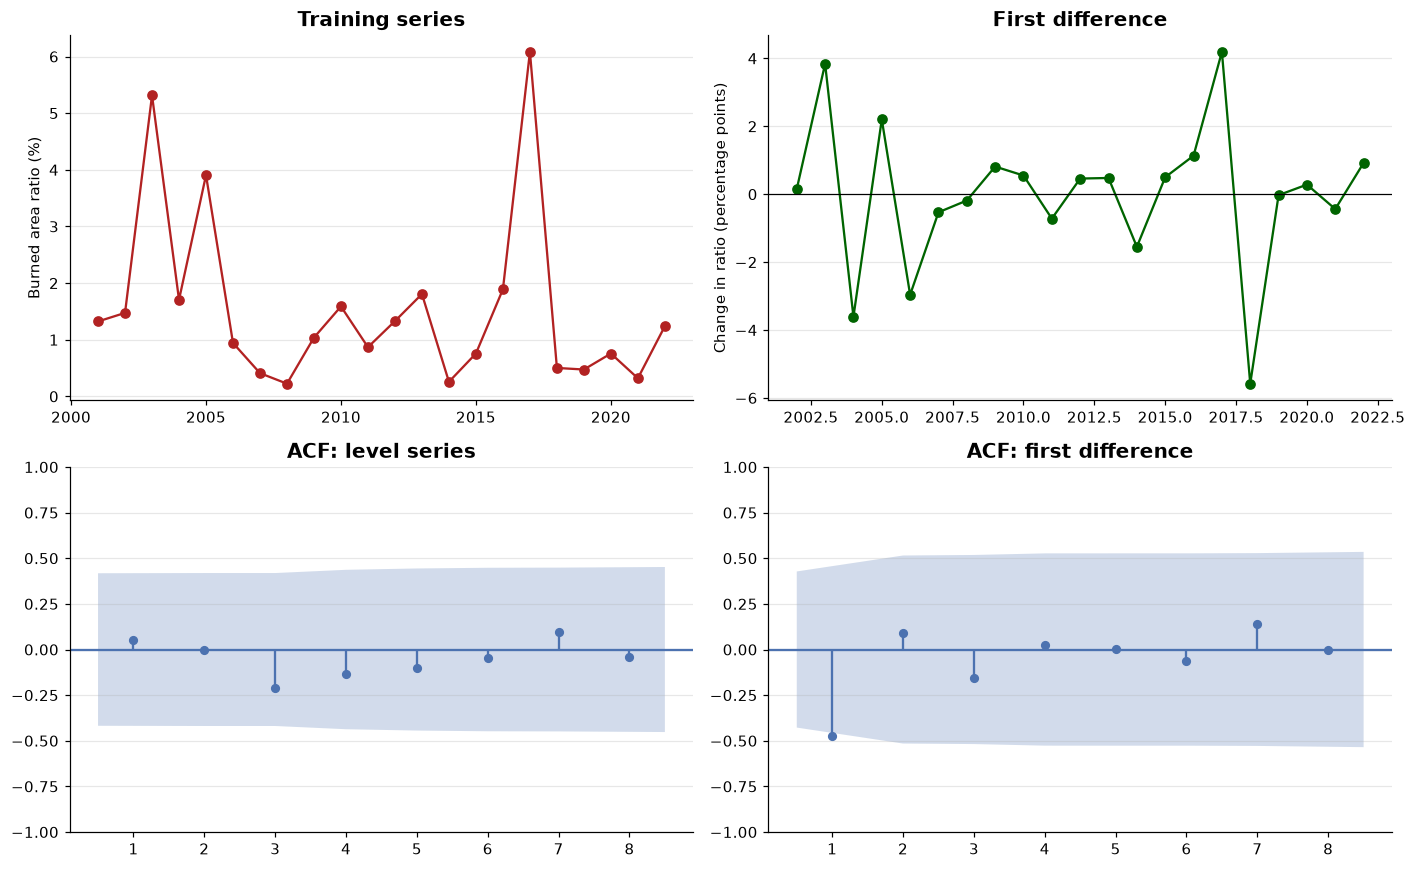

,series,ADF_statistic,ADF_pvalue
0,level,-8.648767,5.183614e-14
1,first_difference,-1.537175,5.150476e-01


In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

raw_adf = adfuller(train, autolag="AIC")
differenced_train = train.diff().dropna()
diff_adf = adfuller(differenced_train, autolag="AIC")

stationarity_checks = pd.DataFrame(
    {
        "series": ["level", "first_difference"],
        "ADF_statistic": [raw_adf[0], diff_adf[0]],
        "ADF_pvalue": [raw_adf[1], diff_adf[1]],
    }
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(train.index, train, marker="o", color="firebrick")
axes[0, 0].set_title("Training series")
axes[0, 0].set_ylabel("Burned area ratio (%)")
axes[0, 1].plot(differenced_train.index, differenced_train, marker="o", color="darkgreen")
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("First difference")
axes[0, 1].set_ylabel("Change in ratio (percentage points)")
plot_acf(train, lags=8, ax=axes[1, 0], zero=False)
axes[1, 0].set_title("ACF: level series")
plot_acf(differenced_train, lags=8, ax=axes[1, 1], zero=False)
axes[1, 1].set_title("ACF: first difference")
fig.tight_layout()
plt.show()

stationarity_checks

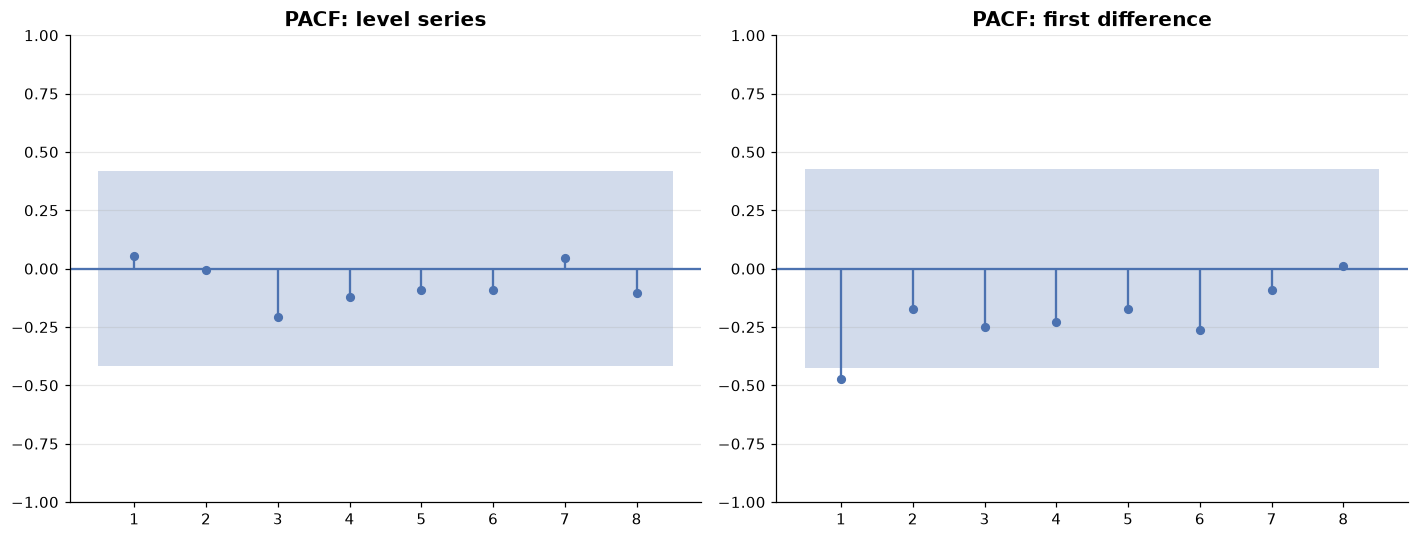

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pacf(train, lags=8, ax=axes[0], method="ywm", zero=False)
axes[0].set_title("PACF: level series")
plot_pacf(differenced_train, lags=8, ax=axes[1], method="ywm", zero=False)
axes[1].set_title("PACF: first difference")
fig.tight_layout()
plt.show()

The level ACF and PACF show no strong low-order spike, so begin with a mean-only model and low-order ARMA alternatives. The differenced plots are retained as a sensitivity check, but they do not justify forcing d=1. Because there are only 22 training observations, model selection will use rolling one-step errors rather than a large ARIMA grid.

In [24]:
arima_orders = {
    "ARIMA(0,0,0)": (0, 0, 0),
    "ARIMA(1,0,0)": (1, 0, 0),
    "ARIMA(0,0,1)": (0, 0, 1),
    "ARIMA(1,0,1)": (1, 0, 1),
}


def arima_forecast(series, order, steps=1, alpha=0.05):
    fitted = sm.tsa.ARIMA(series, order=order, trend="c").fit()
    result = fitted.get_forecast(steps=steps)
    mean = np.asarray(result.predicted_mean, dtype=float)
    interval = result.conf_int(alpha=alpha)
    lower = interval.iloc[:, 0].to_numpy(dtype=float)
    upper = interval.iloc[:, 1].to_numpy(dtype=float)
    return mean, lower, upper


def one_step_forecast(series, model_name):
    if model_name == "historical_mean":
        return float(series.mean())
    if model_name == "naive":
        return float(series.iloc[-1])
    return float(arima_forecast(series, arima_orders[model_name])[0][0])

candidate_models = ["historical_mean", "naive", *arima_orders]
candidate_models

['historical_mean',
 'naive',
 'ARIMA(0,0,0)',
 'ARIMA(1,0,0)',
 'ARIMA(0,0,1)',
 'ARIMA(1,0,1)']

### Select the model with rolling one-step validation

Each candidate is repeatedly fitted using data available up to year t and predicts year t+1. This imitates real forecasting and prevents choosing a model because it performs well only on the final holdout.

Let's use the rolling-origin time-series validation (or walk-forward validation). Basically, instead of fitting the model once, it reapeatedly use first observations to training history and predicts next observation. The expands the training series by one observation until the end.

In [25]:
rolling_rows = []
for model_name in candidate_models:
    actual = []
    predicted = []
    for end_position in range(10, len(train)):
        history = train.iloc[:end_position]
        try:
            prediction = one_step_forecast(history, model_name)
        except (ValueError, np.linalg.LinAlgError):
            prediction = np.nan
        actual.append(float(train.iloc[end_position]))
        predicted.append(prediction)

    rolling_frame = pd.DataFrame({"actual": actual, "predicted": predicted}).dropna()
    rolling_rows.append(
        {
            "model": model_name,
            "validation_observations": len(rolling_frame),
            "MAE": (rolling_frame["predicted"] - rolling_frame["actual"]).abs().mean(),
            "RMSE": np.sqrt(
                ((rolling_frame["predicted"] - rolling_frame["actual"]) ** 2).mean()
            ),
        }
    )

rolling_scores = (
    pd.DataFrame(rolling_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
selected_model = rolling_scores.iloc[0]["model"]
rolling_scores

/opt/homebrew/Caskroom/miniforge/base/envs/wildfires/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/homebrew/Caskroom/miniforge/base/envs/wildfires/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/Caskroom/miniforge/base/envs/wildfires/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/homebrew/Caskroom/miniforge/base/envs/wildfires/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA paramete

,model,validation_observations,MAE,RMSE
0,"ARIMA(0,0,0)",12,1.144591,1.592505
1,historical_mean,12,1.144594,1.592506
2,"ARIMA(0,0,1)",12,1.175548,1.622996
3,"ARIMA(1,0,0)",12,1.185672,1.633760
4,"ARIMA(1,0,1)",12,1.278553,1.701450
5,naive,12,1.356867,2.135634


**Conclusion:** The best predictor is the long-run mean of the series. The simplest model performed best because data do not exhibit a strong predictable temporal pattern. Knowing previous years does not substantially improve prediction relative to simply using the long-run average.

Let's what happens visually.

### Forecast the 2023-2025 years

The selected model is refitted using all training observations through 2022. The final comparison keeps 2023-2025 untouched until this point. Prediction intervals show the range of values compatible with the model, not a guarantee that extreme fires will be covered.

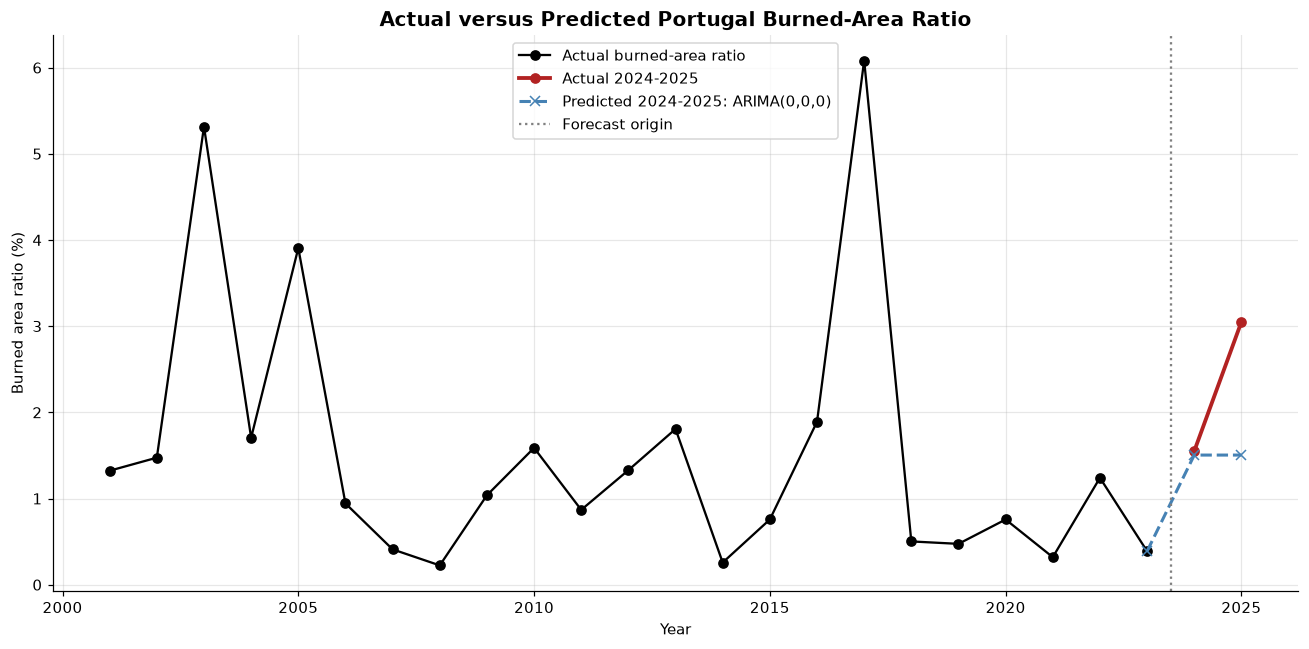

,actual,predicted,absolute_error
year,,,
2024,1.550776,1.504355,0.046422
2025,3.049642,1.504355,1.545287


In [26]:
# forecast 2024-2025 using fire history
forecast_train = country_series.loc[:2023]
forecast_years = pd.Index([2024, 2025], name="year")

if selected_model == "historical_mean":
    forecast_values = np.repeat(forecast_train.mean(), len(forecast_years))
elif selected_model == "naive":
    forecast_values = np.repeat(forecast_train.iloc[-1], len(forecast_years))
else:
    forecast_values = arima_forecast(
        forecast_train,
        arima_orders[selected_model],
        steps=len(forecast_years),
    )[0]

forecast_2024_2025 = pd.DataFrame(
    {
        "actual": country_series.loc[forecast_years].to_numpy(),
        "predicted": forecast_values,
    },
    index=forecast_years,
)
forecast_2024_2025["absolute_error"] = (
    forecast_2024_2025["actual"] - forecast_2024_2025["predicted"]
).abs()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    country_series.loc[:2023].index,
    country_series.loc[:2023],
    color="black",
    marker="o",
    label="Actual burned-area ratio",
)
ax.plot(
    forecast_2024_2025.index,
    forecast_2024_2025["actual"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Actual 2024-2025",
)
ax.plot(
    [2023, *forecast_2024_2025.index],
    [country_series.loc[2023], *forecast_2024_2025["predicted"]],
    color="steelblue",
    marker="x",
    linestyle="--",
    linewidth=2,
    label=f"Predicted 2024-2025: {selected_model}",
)
ax.axvline(2023.5, color="grey", linestyle=":", label="Forecast origin")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area ratio (%)")
ax.set_title("Actual versus Predicted Portugal Burned-Area Ratio")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

forecast_2024_2025

**Conclusion:** The 2025 increase was not predictable from the historical pattern contained in the series. The simple model assumed 2025 would be an "average" year. Instead, 2025 was much higher than average.

## Overall conclusion

The analysis explored whether population ageing and population decline are linked to agricultural fire outcomes.

Results suggest a possible relationship with burned area, but the evidence is not strong enough to draw firm conclusions. Municipalities with a higher share of older residents tended to have slightly higher agricultural burned areas, but the effect became weaker when population change was included in the model.

Importantly, the results were different for fire occurrence and fire impact:
* We found no clear link between demographic change and the number of fires.
* We found some indication that demographic change may be related to how much land burns when fires occur.

At the national level, past fire patterns were not very useful for forecasting future burned areas. A simple average-based forecast performed as well as more complex models, and it did not anticipate the large increase observed in 2025.

Overall, the current data does not provide strong evidence that ageing or depopulation directly increase fire risk, but it also does not rule out a relationship.

### Why the link may not be clear

Several factors may explain the inconclusive results:
* The demographic dataset covers only a short period (2019-2024).
* Effects of ageing and depopulation may take many years to appear.
* Key factors such as land abandonment, vegetation growth, weather conditions, and firefighting capacity were not directly measured.
* Fire outcomes are heavily influenced by drought, wind, and other environmental conditions that can outweigh demographic effects.
* Neighbor municipalities were not considered (e.g. a fire may pass from one municipality to the other but this relationship was not modeled).

### Key take aways
* Fire counts misrepresent damage; burned-area ratio is the defensible outcome measure.
* With municipality and year fixed effects, ageing carries a positive but marginal coefficient (0.661, p = 0.042) that weakens once population change is included.
* Demographic change shows no clear link to fire occurrence, and only limited evidence of a link to fire impact.
* National burned area is not predictable from its own history — the long-run mean beats every fitted time-series model, and 2025 was far above it.

### Recommendations for future analysis

A stronger assessment would require:
* Longer demographic and population histories.
* Better measures of rural decline and land abandonment.
* Weather and drought information.
* Land management and vegetation indicators.
* Testing delayed effects, where demographic change influences fire outcomes several years later.

With these additional data sources, it would be possible to determine more confidently whether demographic change contributes to agricultural fire risk or severity.